In [1]:
!pip install openai-whisper pybind11


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 12.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=615cfdea74b4b2f7ee592b0c6dd97278958c304f5c4726c39fa850eaeff33413
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [2]:
#compile my c++ tokenizer using pybind11, so I can use it in python as a module
!export EXT=$(python3 -c "import sysconfig; print(sysconfig.get_config_var('EXT_SUFFIX'))") && \
 export SRC="/kaggle/input/datasets/aneeshshastri/custom-tokenizers/bpe_tokenizer.cpp" && \
 g++ -O3 -Wall -shared -std=c++17 -fPIC $(python3 -m pybind11 --includes) $SRC -o /kaggle/working/bpe_tokenizer$EXT



### Custom Tokenizer:

For a different project that was about building an LLM from scratch, I had designed a custom C++ BPE based tokenizer. I decided it was appropriate to use it here, and so I did. The C++ code for it should be present in the same folder as this notebook in my Github Repository.

In [3]:
#import libraries 
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax
import pathlib
import librosa
import numpy as np
import math
import os
import whisper
import bpe_tokenizer
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42


In [4]:

root_path = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"
for item in sorted(os.listdir(root_path)):
    print(item, end=" ")
    
    

Actor_01 Actor_02 Actor_03 Actor_04 Actor_05 Actor_06 Actor_07 Actor_08 Actor_09 Actor_10 Actor_11 Actor_12 Actor_13 Actor_14 Actor_15 Actor_16 Actor_17 Actor_18 Actor_19 Actor_20 Actor_21 Actor_22 Actor_23 Actor_24 audio_speech_actors_01-24 

### There seems to be a hidden folder I can't access directly for some reason. This folder seems to contains of all the files from Actor_01 to Actor_24. I'll use this is as the root directory to get my dataset

### The files in the dataset follow the following naming convention:
    Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor.wav
                        Eg: 03-01-01-01-01-01-01.wav

**Modality:** 01= Video and Audio, 02=Video only, 03= Audio only \
**VocalChannel** 01=speech, 02=song \
(In our case, the entire dataset has modality 03 and vocal channel 01)

**Emotion:** 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful,  07=disgust, 08 = surprised\
**Intensity:** 01 = normal, 02 = strong (There is no strong intensity for the 'neutral' emotion) \
**Statement:** 01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door"\
**Repetition:** 01= 1st repetition, 02 = 2nd repetition\
**Actor:** 01 to 24 (Odd numbered actors are male, even numbered actors are female)

In [5]:
#================Parse the dataset========
def parse_ravdess(root: str) -> list[dict]:
    records = []
    for path in sorted(pathlib.Path(root).rglob("*.wav")):
        parts = path.stem.split('-')
        records.append({
            "path":      str(path),
            "label":     EMOTION_MAP[parts[2]],
            "actor":     int(parts[6]),
            "intensity": int(parts[3]),
        })

    print(f"Parsed {len(records)} files ")
    return records


In [6]:
#--Configs--

NUM_CLASSES = 8
BATCH_SIZE  = 32

RAVDESS_INPUT      = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24"
TRANSCRIPTS_OUTPUT = "/kaggle/working/ravdess_transcripts"
CACHE_DIR          = "/kaggle/working/cache"
LOGITS_DIR         = "/kaggle/working/loso_logits"

EMOTION_MAP = {
    '01': 0,  # neutral
    '02': 1,  # calm
    '03': 2,  # happy
    '04': 3,  # sad
    '05': 4,  # angry
    '06': 5,  # fearful
    '07': 6,  # disgust
    '08': 7,  # surprised
}

EMOTION_LABELS = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised",
]

MEL_CFG = dict(
    sr         = 22050,
    n_fft      = 1024,
    hop_length = 256,       # ~11.6 ms stride at 22 kHz
    n_mels     = 128,
    fmin       = 50,
    fmax       = 8000,
    duration   = 3.0,
)


In [7]:
#======== Transcribe the audio files==========

def transcribe_corpus(records: list[dict], output_path: str,
                      model_size: str = "base") -> str:
    """
    Transcribe audio files from parsed records using Whisper.
    Skips entirely if transcripts already exist on disk.
    """
    out_dir = Path(output_path)

    # reuse existing transcripts
    if out_dir.exists():
        existing = sorted(out_dir.glob("*.txt"))
        if len(existing) >= len(records):
            print(f"Found {len(existing)} existing transcripts in "
                  f"{output_path}. Skipping Whisper transcription.")
            return " ".join(f.read_text(encoding="utf-8") for f in existing)

    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"Transcribing {len(records)} files with Whisper '{model_size}'...")
    model = whisper.load_model(model_size)
    corpus_texts = []

    for rec in tqdm(records, desc="Transcribing RAVDESS"):
        audio_path = Path(rec["path"])
        result = model.transcribe(
            str(audio_path),
            temperature=0.0,
            condition_on_previous_text=False,
            no_speech_threshold=0.6,
        )
        transcription = result["text"].strip()
        (out_dir / f"{audio_path.stem}.txt").write_text(
            transcription, encoding="utf-8"
        )
        corpus_texts.append(transcription)

    return " ".join(corpus_texts) #return the total text data to train our tokenizer 


In [8]:
# ── Audio Preprocessing ───────────────────────────────────────────────────────
# Load and convert into a log mel spectrogram of dimensions (H,W,1)
def load_melspec(path: str, cfg: dict = MEL_CFG) -> np.ndarray:
    wav, _ = librosa.load(path, sr=cfg["sr"], mono=True)
    target_len = int(cfg["sr"] * cfg["duration"])

    if len(wav) < target_len:
        wav = np.pad(wav, (0, target_len - len(wav)))
    else:
        wav = wav[:target_len]

    mel = librosa.feature.melspectrogram(
        y=wav, sr=cfg["sr"], n_fft=cfg["n_fft"],
        hop_length=cfg["hop_length"], n_mels=cfg["n_mels"],
        fmin=cfg["fmin"], fmax=cfg["fmax"],
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)          # (n_mels, T)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    return log_mel[..., np.newaxis].astype(np.float32)       # (128, T, 1)

#Compute mel spectrograms for all records, and also cache to disk to avoid unnecessary recomputation
def preprocess_audio_cache(records: list[dict], cache_dir: str):
    
    cache = pathlib.Path(cache_dir)
    cache.mkdir(exist_ok=True)

    specs, labels = [], []
    for rec in tqdm(records, desc="Caching mel spectrograms"):
        npy_path = cache / (pathlib.Path(rec["path"]).stem + ".npy")
        if not npy_path.exists():
            mel = load_melspec(rec["path"])
            np.save(npy_path, mel)
        else:
            mel = np.load(npy_path)
        specs.append(mel)
        labels.append(rec["label"])

    X = np.stack(specs)
    y = np.array(labels, dtype=np.int32)
    np.save(cache / "X.npy", X)
    np.save(cache / "y.npy", y)
    return X, y


In [9]:
# ── Text Preprocessing ────────────────────────────────────────────────────────
"""
    Load transcript .txt files, BPE-encode them, and pad into
    a static-shaped matrix suitable for XLA / JAX.
    Returns (X_text, max_len, pad_id).
"""
def preprocess_transcriptions(tokenizer, root_dir: str):
    
    root_path = Path(root_dir)
    if not root_path.exists() or not root_path.is_dir():
        raise FileNotFoundError(f"Transcript directory not found: {root_dir}")

    txt_files = sorted(root_path.rglob("*.txt"))
    if not txt_files:
        raise ValueError(f"No .txt files found in {root_dir}")

    print(f"Discovered {len(txt_files)} transcript files. Encoding...")
    encoded_sequences = []
    for txt_path in tqdm(txt_files, desc="Encoding Text"):
        text = txt_path.read_text(encoding="utf-8").strip()
        encoded_sequences.append(tokenizer.encode(text))

    max_len = max(len(seq) for seq in encoded_sequences)
    pad_id  = tokenizer.get_vocab_size()   # pad token = vocab_size
    print(f"Max sequence length: {max_len} tokens | PAD_ID: {pad_id}")

    X_text = np.full((len(encoded_sequences), max_len), pad_id, dtype=np.int32)
    for i, seq in enumerate(encoded_sequences):
        X_text[i, :len(seq)] = seq

    return X_text, max_len, pad_id


In [10]:
# ── Execute Preprocessing Pipeline ────────────────────────────────────────────

#  Parse dataset
records = parse_ravdess(RAVDESS_INPUT)

#  Transcribe
full_corpus_string = transcribe_corpus(records, TRANSCRIPTS_OUTPUT, model_size="base")
print(f"Total characters in corpus: {len(full_corpus_string)}")

#  Train BPE tokenizer on corpus
Tokenizer = bpe_tokenizer.BPETokenizer()
Tokenizer.train(full_corpus_string, num_merges=1_000)
VOCAB_SIZE = Tokenizer.get_vocab_size()
print(f"Vocab size: {VOCAB_SIZE}")

#  Compute mel spectrograms
X_audio, y = preprocess_audio_cache(records, CACHE_DIR)
print(f"X_audio shape: {X_audio.shape} | y shape: {y.shape}")

# 5. Encode transcripts
X_text, MAX_SEQ_LEN, PAD_ID = preprocess_transcriptions(Tokenizer, TRANSCRIPTS_OUTPUT)
print(f"X_text shape: {X_text.shape}")


Parsed 1440 files 
Transcribing 1440 files with Whisper 'base'...


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 112MiB/s]
Transcribing RAVDESS: 100%|██████████| 1440/1440 [07:15<00:00,  3.31it/s]


Total characters in corpus: 43347
Vocab size: 446


Caching mel spectrograms: 100%|██████████| 1440/1440 [00:35<00:00, 40.99it/s]


X_audio shape: (1440, 128, 259, 1) | y shape: (1440,)
Discovered 1440 transcript files. Encoding...


Encoding Text: 100%|██████████| 1440/1440 [00:00<00:00, 5033.92it/s]

Max sequence length: 12 tokens | PAD_ID: 446
X_text shape: (1440, 12)


#### Since the dataset is small (<400MB) I'm loading the whole thing directly into VRAM. This isn't scalable, and I'll build a seperate dataloader using grain to load and transfer data batchwise from disk->system RAM-> GPU VRAM if the dataset exceeds 2 gigabytes in size. Loading everythin into VRAM right now prevents me from getting stuck with a CPU bottleneck

In [11]:
#============================ Train / Val / Test Split + VRAM Transfer======================

# First split: 80% train+val, 20% test
X_audio_tv, X_audio_test, X_text_tv, X_text_test, y_tv, y_test = train_test_split(
    X_audio, X_text, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Second split: 90% train, 10% val (of the remaining 80%)
X_audio_train, X_audio_val, X_text_train, X_text_val, y_train, y_val = train_test_split(
    X_audio_tv, X_text_tv, y_tv, test_size=0.1, random_state=RANDOM_SEED, stratify=y_tv,
)


X_audio_train = jax.device_put(X_audio_train)
X_audio_val   = jax.device_put(X_audio_val)
X_audio_test  = jax.device_put(X_audio_test)

X_text_train  = jax.device_put(X_text_train)
X_text_val    = jax.device_put(X_text_val)
X_text_test   = jax.device_put(X_text_test)

y_train = jax.device_put(y_train)
y_val   = jax.device_put(y_val)
y_test  = jax.device_put(y_test)

print(f"Train: audio {X_audio_train.shape}, text {X_text_train.shape}, labels {y_train.shape}")
print(f"Val:   audio {X_audio_val.shape},   text {X_text_val.shape},   labels {y_val.shape}")
print(f"Test:  audio {X_audio_test.shape},  text {X_text_test.shape},  labels {y_test.shape}")


Train: audio (1036, 128, 259, 1), text (1036, 12), labels (1036,)
Val:   audio (116, 128, 259, 1),   text (116, 12),   labels (116,)
Test:  audio (288, 128, 259, 1),  text (288, 12),  labels (288,)


In [12]:
# ===============================Batching Utility========================================

def get_vram_batches(X, y, batch_size=BATCH_SIZE, shuffle=True, seed=42):
    """
    Yield {"input": ..., "labels": ...} batches from VRAM arrays.
    Keeps the final partial batch instead of dropping it.
    """
    num_samples = len(y)
    indices = np.arange(num_samples)

    if shuffle:
        np.random.default_rng(seed).shuffle(indices)

    num_batches = math.ceil(num_samples / batch_size)
    for i in range(num_batches):
        idx = indices[i * batch_size : min((i + 1) * batch_size, num_samples)]
        if len(idx) == 0:
            continue
        yield {"input": X[idx], "labels": y[idx]}


In [13]:
#========== Spectogram augmentation to combat overfitting===========
class SpecAugment(nnx.Module):
    """Frequency + time masking for mel spectrograms (SpecAugment)."""

    def __init__(self, freq_mask_param: int, time_mask_param: int, rngs: nnx.Rngs):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        # Store the full Rngs object so each forward pass draws a fresh key.
        self.rngs = rngs

    def __call__(self, x: jnp.ndarray, training: bool) -> jnp.ndarray:
        if not training:
            return x

        B, T_dim, F_dim = x.shape
        key = self.rngs.augmentation()
        key_f, key_f0, key_t, key_t0 = jax.random.split(key, 4)

        f  = jax.random.randint(key_f,  (B, 1, 1), 0, self.freq_mask_param)
        f0 = jax.random.randint(key_f0, (B, 1, 1), 0, F_dim)
        t  = jax.random.randint(key_t,  (B, 1, 1), 0, self.time_mask_param)
        t0 = jax.random.randint(key_t0, (B, 1, 1), 0, T_dim)

        freq_idx = jnp.arange(F_dim).reshape(1, 1, F_dim)
        time_idx = jnp.arange(T_dim).reshape(1, T_dim, 1)

        freq_mask = (freq_idx < f0) | (freq_idx >= f0 + f)
        time_mask = (time_idx < t0) | (time_idx >= t0 + t)

        x = jnp.where(freq_mask, x, 0.0)
        x = jnp.where(time_mask, x, 0.0)
        return x

In [14]:
#========= CNN Architecture=====================


class Conv1DBlock(nnx.Module):
    """1D Conv -> BatchNorm -> GELU -> MaxPool1D"""

    def __init__(self, in_features: int, out_features: int, rngs: nnx.Rngs):
        self.conv = nnx.Conv(
            in_features=in_features, out_features=out_features,
            kernel_size=(3,), padding="SAME", rngs=rngs,
        )
        self.bn = nnx.BatchNorm(num_features=out_features, rngs=rngs)

    def __call__(self, x: jnp.ndarray, training: bool) -> jnp.ndarray:
        x = self.conv(x)
        x = self.bn(x, use_running_average=not training)
        x = jax.nn.gelu(x)
        x = jax.lax.reduce_window(
            x, -jnp.inf, jax.lax.max,
            window_dimensions=(1, 2, 1), window_strides=(1, 2, 1),
            padding="VALID",
        )
        return x


# ── 1D CNN Backbone ──────────────────────────────────────────────────────────

class CNN1DBackbone(nnx.Module):
    def __init__(self, rngs: nnx.Rngs):
        self.block1 = Conv1DBlock(in_features=128, out_features=64,  rngs=rngs)
        self.block2 = Conv1DBlock(in_features=64,  out_features=128, rngs=rngs)
        self.block3 = Conv1DBlock(in_features=128, out_features=256, rngs=rngs)

    def __call__(self, x: jnp.ndarray, training: bool) -> jnp.ndarray:
        x = self.block1(x, training)   # (B, 129, 64)
        x = self.block2(x, training)   # (B, 64, 128)
        x = self.block3(x, training)   # (B, 32, 256)
        return x



# ── Audio Model: 1D-CNN ────────────────────────────────────────────────────
#    1D CNN Backbone -> Global Max Pool -> Classifier

class EmotionCNN(nnx.Module):

    def __init__(self, num_classes: int = NUM_CLASSES,
                 gru_hidden: int = 128, rngs: nnx.Rngs = None):
        self.spec_augment = SpecAugment(
            freq_mask_param=20, time_mask_param=30, rngs=rngs,
        )
        self.cnn     = CNN1DBackbone(rngs)
        self.connect = nnx.Linear(256, gru_hidden, rngs=rngs)
        self.dropout = nnx.Dropout(rate=0.3, rngs=rngs)
        self.fc1     = nnx.Linear(gru_hidden, 64, rngs=rngs)
        self.fc2     = nnx.Linear(64, num_classes, rngs=rngs)
        self.gru_hidden = gru_hidden

    def __call__(self, x: jnp.ndarray, training: bool = True) -> jnp.ndarray:
        # Input: (B, 128, 259, 1)
        x = jnp.squeeze(x, axis=-1)        # (B, 128, 259)
        x = jnp.transpose(x, (0, 2, 1))    # (B, 259, 128)
        x = self.spec_augment(x, training=training)

        x = self.cnn(x, training)           # (B, 32, 256)

        x = jnp.max(x, axis=1)             # Global max pool -> (B, 256)
        x = jax.nn.gelu(self.connect(x))
        x = self.dropout(x, deterministic=not training)
        x = jax.nn.gelu(self.fc1(x))
        return self.fc2(x)

In [15]:
# =========Text Model Architecture: GRU-based RNN ==================

class TextRNN(nnx.Module):
    def __init__(self, vocab_size: int, pad_id: int,
                 embed_dim: int, hidden_dim: int,
                 num_classes: int, rngs: nnx.Rngs):
        self.pad_id = pad_id
        self.embed  = nnx.Embed(num_embeddings=vocab_size + 1,
                                features=embed_dim, rngs=rngs)
        self.cell   = nnx.GRUCell(in_features=embed_dim,
                                  hidden_features=hidden_dim, rngs=rngs)
        self.rnn    = nnx.RNN(self.cell)
        self.dropout    = nnx.Dropout(rate=0.3, rngs=rngs)
        self.classifier = nnx.Linear(in_features=hidden_dim,
                                     out_features=num_classes, rngs=rngs)

    def __call__(self, x: jax.Array, training: bool = True) -> jax.Array:
        mask = (x != self.pad_id)
        emb  = self.embed(x)
        rnn_out = self.rnn(emb)

        # Masked mean pooling
        mask_exp    = jnp.expand_dims(mask, axis=-1)
        sum_hidden  = jnp.sum(rnn_out * mask_exp, axis=1)
        valid_lens  = jnp.maximum(jnp.sum(mask, axis=1, keepdims=True), 1)
        pooled      = sum_hidden / valid_lens

        x_drop = self.dropout(pooled, deterministic=not training)
        return self.classifier(x_drop)


### On Class-weighted loss and accuracy

I've noticed that the neutral class is underrepresented in the dataset, containing only half the files the other classes do.I've weighed the loss and accuracy based on class frequency as a simple measure to combat this class Imbalance. 

In [16]:
# ==== Early Stopping with Best-Weight Restore =======

class EarlyStopping:
    """Monitors val loss, snapshots best weights, restores on stop."""
    def __init__(self, patience: int = 30, min_delta: float = 0.0):
        self.patience, self.min_delta = patience, min_delta
        self.best_loss, self.wait = float("inf"), 0
        self.best_state, self.best_epoch, self.stopped_epoch = None, -1, -1

    def step(self, val_loss: float, model, epoch: int) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.wait, self.best_epoch = val_loss, 0, epoch
            _, self.best_state = nnx.split(model)
            return False
        self.wait += 1
        if self.wait >= self.patience:
            self.stopped_epoch = epoch
            return True
        return False

    def restore(self, model):
        if self.best_state is not None:
            nnx.update(model, self.best_state)
            print(f"Restored best weights from epoch {self.best_epoch} (val_loss={self.best_loss:.4f})")


#  ======================== Class-Weighted Loss & Metrics ========================

def compute_class_weights(labels: np.ndarray, num_classes: int = NUM_CLASSES) -> jnp.ndarray:
    """Inverse-frequency weights, normalised so they sum to num_classes."""
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    counts = np.maximum(counts, 1)          # avoid div-by-zero for absent classes
    inv_freq = 1.0 / counts
    weights = inv_freq / inv_freq.sum() * num_classes
    return jnp.array(weights)


def weighted_xent(logits, labels, class_weights):
    """Per-sample weighted softmax cross-entropy, averaged over the batch."""
    per_sample = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
    sample_weights = class_weights[labels]
    return (per_sample * sample_weights).mean()


def create_metric_tracker():
    return nnx.MultiMetric(
        loss=nnx.metrics.Average('loss'),
        weighted_acc=nnx.metrics.Average('weighted_acc'),
    )

### Along with class weighted Accuracy , I also added these additional metrics.
(macro F1 score, balanced accuracy , precision and recall)

In the following cell, we have a few utility functions involved in making near plots

In [17]:
def metrics_to_python(metric_values):
    return {key: float(value) for key, value in metric_values.items()}


def compute_prediction_metrics(labels, preds, class_weights=None, sample_weights=None, loss=None):
    labels = np.asarray(labels).astype(np.int32)
    preds = np.asarray(preds).astype(np.int32)

    if sample_weights is None and class_weights is not None:
        class_weights = np.asarray(class_weights, dtype=np.float32)
        sample_weights = class_weights[labels]

    cm = confusion_matrix(labels, preds, labels=np.arange(NUM_CLASSES))
    balanced_acc = float(balanced_accuracy_score(labels, preds))
    accuracy = float(accuracy_score(labels, preds))
    weighted_acc = (
        float(np.average((preds == labels).astype(np.float32), weights=sample_weights))
        if sample_weights is not None else accuracy
    )
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(NUM_CLASSES),
        average="macro",
        zero_division=0,
    )

    return {
        "loss": None if loss is None else float(loss),
        "weighted_acc": weighted_acc,
        "balanced_acc": balanced_acc,
        "accuracy": accuracy,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "confusion_matrix": cm,
        "labels": labels,
        "preds": preds,
    }


def print_evaluation_summary(results, title=None):
    if title:
        print(title)
    print("-" * 40)
    if results["loss"] is not None:
        print(f"  Weighted Loss:     {results['loss']:.4f}")
    print(f"  Weighted Accuracy: {results['weighted_acc']:.4f}")
    print(f"  Balanced Accuracy: {results['balanced_acc']:.4f}")
    print(f"  Regular Accuracy:  {results['accuracy']:.4f}")
    print(f"  Precision:         {results['precision']:.4f}")
    print(f"  Recall:            {results['recall']:.4f}")
    print(f"  F1 Score:          {results['f1']:.4f}")
    print("  Confusion Matrix:")
    print(results["confusion_matrix"])
    print("-" * 40)


def plot_training_histories(histories, title):
    fig, axes = plt.subplots(1, len(histories), figsize=(7 * len(histories), 5))
    if len(histories) == 1:
        axes = [axes]

    for ax, (model_name, history) in zip(axes, histories.items()):
        train_epochs = np.arange(1, len(history["train_epoch_loss"]) + 1)
        val_epochs = np.arange(1, len(history["val_epoch_loss"]) + 1)

        ax.plot(train_epochs, history["train_epoch_loss"], label="Train Loss", linewidth=1.8)
        ax.plot(val_epochs, history["val_epoch_loss"], label="Validation Loss", linewidth=1.8)
        ax.set_title(model_name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        if history.get("best_epoch") is not None and history["best_epoch"] >= 0:
            ax.axvline(history["best_epoch"] + 1, color="gray", linestyle="--", linewidth=1.0, alpha=0.7)
            ax.text(
                0.02,
                0.98,
                f"Best epoch: {history['best_epoch'] + 1}",
                transform=ax.transAxes,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75),
            )
        ax.legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_confusion_heatmaps(results_by_model, class_names=EMOTION_LABELS, title="Confusion Matrix Heatmaps"):
    fig, axes = plt.subplots(1, len(results_by_model), figsize=(6 * len(results_by_model), 5))
    if len(results_by_model) == 1:
        axes = [axes]

    max_value = max(result["confusion_matrix"].max() for result in results_by_model.values())
    color_ref = None

    for ax, (model_name, result) in zip(axes, results_by_model.items()):
        cm = result["confusion_matrix"]
        color_ref = ax.imshow(cm, cmap="Blues", vmin=0, vmax=max_value)
        ax.set_title(model_name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)

        threshold = max_value / 2 if max_value > 0 else 0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j,
                    i,
                    int(cm[i, j]),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > threshold else "black",
                )

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

In [18]:
# ============CREATE MODEL+OPTIMIZER===================

def create_audio_model_and_optimizer(lr: float = 3e-4):
    rngs  = nnx.Rngs(params=0, dropout=1, batch_stats=2, augmentation=3)
    model = EmotionCNN(num_classes=NUM_CLASSES, gru_hidden=128, rngs=rngs)
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=lr,
        warmup_steps=200, decay_steps=5000, end_value=1e-6,
    )
    opt = nnx.Optimizer(model, optax.adamw(schedule, weight_decay=1e-4), wrt=nnx.Param)
    return model, opt


def create_text_model_and_optimizer(vocab_size: int, pad_id: int, lr: float = 3e-4):
    rngs  = nnx.Rngs(params=0, dropout=1)
    model = TextRNN(
        vocab_size=vocab_size, pad_id=pad_id,
        embed_dim=64, hidden_dim=128,
        num_classes=NUM_CLASSES, rngs=rngs,
    )
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=lr,
        warmup_steps=100, decay_steps=2000, end_value=1e-6,
    )
    opt = nnx.Optimizer(model, optax.adamw(schedule, weight_decay=1e-4), wrt=nnx.Param)
    return model, opt



#============train and validation step functions===============

@nnx.jit
def train_step(model, optimizer, metrics, batch, class_weights):
    def loss_fn(model):
        logits = model(batch["input"], training=True)
        loss = weighted_xent(logits, batch["labels"], class_weights)
        return loss, logits

    (loss, logits), grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
    optimizer.update(model, grads)

    preds   = jnp.argmax(logits, axis=-1)
    correct = (preds == batch["labels"]).astype(jnp.float32)
    sw      = class_weights[batch["labels"]]
    w_acc   = (correct * sw).sum() / sw.sum()

    metrics.update(loss=loss, weighted_acc=w_acc)
    return loss


@nnx.jit
def eval_step(model, metrics, batch, class_weights):
    logits = model(batch["input"], training=False)
    loss   = weighted_xent(logits, batch["labels"], class_weights)

    preds   = jnp.argmax(logits, axis=-1)
    correct = (preds == batch["labels"]).astype(jnp.float32)
    sw      = class_weights[batch["labels"]]
    w_acc   = (correct * sw).sum() / sw.sum()

    metrics.update(loss=loss, weighted_acc=w_acc)
    return loss


# ======Collect and Store logits for late_fusion model training.==========

def collect_logits(model, X, batch_size=BATCH_SIZE):
    """Run inference on X and return raw logits as a NumPy array."""
    model.eval()
    parts = []
    n = len(X)
    for i in range(math.ceil(n / batch_size)):
        s, e = i * batch_size, min((i + 1) * batch_size, n)
        logits = model(X[s:e], training=False)
        parts.append(np.array(logits))
    return np.concatenate(parts, axis=0)


# ======== Test-Set Evaluation (weighted) ==================

def evaluate_test_set(model, X_test, y_test, class_weights, batch_size=BATCH_SIZE, title=None):
    """Evaluate on the held-out test set with weighted metrics and confusion matrix."""
    all_logits = collect_logits(model, X_test, batch_size)
    all_labels = np.array(y_test)
    preds = np.argmax(all_logits, axis=-1)

    loss = float(weighted_xent(
        jnp.array(all_logits), jnp.array(all_labels), class_weights
    ))
    results = compute_prediction_metrics(
        all_labels,
        preds,
        class_weights=class_weights,
        loss=loss,
    )
    results["logits"] = all_logits

    print_evaluation_summary(results, title=title)
    return results

In [19]:
#===============Train CNN based Audio model==============

AUDIO_EPOCHS = 300
audio_model, audio_optimizer = create_audio_model_and_optimizer()

# Compute class weights from training labels
audio_cw = compute_class_weights(np.array(y_train))

metrics = create_metric_tracker()
val_metrics = create_metric_tracker()
audio_es = EarlyStopping(patience=50)
audio_history = {
    "train_steps": [],
    "train_losses": [],
    "val_steps": [],
    "val_losses": [],
    "train_epoch_loss": [],
    "val_epoch_loss": [],
    "best_epoch": None,
}
audio_train_step = 0
audio_val_step = 0

print("Training EmotionCNN (audio)...")
for epoch in range(AUDIO_EPOCHS):
    audio_model.train()
    for batch in get_vram_batches(X_audio_train, y_train, shuffle=True, seed=epoch):
        loss = float(train_step(audio_model, audio_optimizer, metrics, batch, audio_cw))
        audio_train_step += 1
        audio_history["train_steps"].append(audio_train_step)
        audio_history["train_losses"].append(loss)

    audio_model.eval()
    for batch in get_vram_batches(X_audio_val, y_val, shuffle=False):
        loss = float(eval_step(audio_model, val_metrics, batch, audio_cw))
        audio_val_step += 1
        audio_history["val_steps"].append(audio_val_step)
        audio_history["val_losses"].append(loss)

    train_stats = metrics_to_python(metrics.compute())
    vc = metrics_to_python(val_metrics.compute())
    audio_history["train_epoch_loss"].append(train_stats["loss"])
    audio_history["val_epoch_loss"].append(vc["loss"])
    print(f"Epoch {epoch:3d} | Train: {train_stats} | Val: {vc}")
    metrics.reset(); val_metrics.reset()

    if audio_es.step(float(vc['loss']), audio_model, epoch):
        print(f"Early stopping at epoch {epoch}")
        break

audio_es.restore(audio_model)
audio_history["best_epoch"] = audio_es.best_epoch


Training EmotionCNN (audio)...
Epoch   0 | Train: {'loss': 2.233861207962036, 'weighted_acc': 0.127699613571167} | Val: {'loss': 1.981174111366272, 'weighted_acc': 0.11507785320281982}
Epoch   1 | Train: {'loss': 2.083090305328369, 'weighted_acc': 0.1435178518295288} | Val: {'loss': 1.9816949367523193, 'weighted_acc': 0.11507785320281982}
Epoch   2 | Train: {'loss': 2.003269672393799, 'weighted_acc': 0.18043282628059387} | Val: {'loss': 1.9808903932571411, 'weighted_acc': 0.11507785320281982}
Epoch   3 | Train: {'loss': 1.941912055015564, 'weighted_acc': 0.19058285653591156} | Val: {'loss': 1.9750792980194092, 'weighted_acc': 0.11507785320281982}
Epoch   4 | Train: {'loss': 1.9204306602478027, 'weighted_acc': 0.1992502510547638} | Val: {'loss': 1.9617295265197754, 'weighted_acc': 0.19017517566680908}
Epoch   5 | Train: {'loss': 1.8679009675979614, 'weighted_acc': 0.21274806559085846} | Val: {'loss': 1.9340388774871826, 'weighted_acc': 0.23657748103141785}
Epoch   6 | Train: {'loss': 1.

### Note on the Text Model:


#### The text model is pretty useless for this specific dataset, as the actors only ever speak two sentences, both of which care no hints about the underlying emotion. This leads my model to try and overfit on noise (Errors or retained punctuation while transcribing), and eventually getting an extremely bad scores during evaluation. Even at ideal performance, text models on this dataset would not outperform random guessing to any significant degree

In [20]:
#===========Text Model Training==================

TEXT_EPOCHS = 100
txt_model, txt_optimizer = create_text_model_and_optimizer(vocab_size=VOCAB_SIZE, pad_id=PAD_ID)
metrics = create_metric_tracker()
val_metrics = create_metric_tracker()
text_es = EarlyStopping(patience=20)
text_history = {
    "train_steps": [],
    "train_losses": [],
    "val_steps": [],
    "val_losses": [],
    "train_epoch_loss": [],
    "val_epoch_loss": [],
    "best_epoch": None,
}
text_train_step = 0
text_val_step = 0

print("Training TextRNN...")
for epoch in range(TEXT_EPOCHS):
    txt_model.train()
    for batch in get_vram_batches(X_text_train, y_train, shuffle=True, seed=epoch):
        loss = float(train_step(txt_model, txt_optimizer, metrics, batch, audio_cw))
        text_train_step += 1
        text_history["train_steps"].append(text_train_step)
        text_history["train_losses"].append(loss)

    txt_model.eval()
    for batch in get_vram_batches(X_text_val, y_val, shuffle=False):
        loss = float(eval_step(txt_model, val_metrics, batch, audio_cw))
        text_val_step += 1
        text_history["val_steps"].append(text_val_step)
        text_history["val_losses"].append(loss)

    train_stats = metrics_to_python(metrics.compute())
    vc = metrics_to_python(val_metrics.compute())
    text_history["train_epoch_loss"].append(train_stats["loss"])
    text_history["val_epoch_loss"].append(vc["loss"])
    print(f"Epoch {epoch:3d} | Train: {train_stats} | Val: {vc}")
    metrics.reset(); val_metrics.reset()

    if text_es.step(float(vc['loss']), txt_model, epoch):
        print(f"Early stopping at epoch {epoch}")
        break

text_es.restore(txt_model)
text_history["best_epoch"] = text_es.best_epoch


Training TextRNN...
Epoch   0 | Train: {'loss': 1.972364902496338, 'weighted_acc': 0.1306810826063156} | Val: {'loss': 1.9862902164459229, 'weighted_acc': 0.08074559271335602}
Epoch   1 | Train: {'loss': 1.9705525636672974, 'weighted_acc': 0.10694295912981033} | Val: {'loss': 1.9855656623840332, 'weighted_acc': 0.0978299081325531}
Epoch   2 | Train: {'loss': 1.9721038341522217, 'weighted_acc': 0.13746699690818787} | Val: {'loss': 1.9860845804214478, 'weighted_acc': 0.07457249611616135}
Epoch   3 | Train: {'loss': 1.975362777709961, 'weighted_acc': 0.12156365066766739} | Val: {'loss': 1.9854187965393066, 'weighted_acc': 0.06722253561019897}
Epoch   4 | Train: {'loss': 1.9685982465744019, 'weighted_acc': 0.12466078996658325} | Val: {'loss': 1.98392653465271, 'weighted_acc': 0.11001879721879959}
Epoch   5 | Train: {'loss': 1.9670603275299072, 'weighted_acc': 0.125663161277771} | Val: {'loss': 1.9848358631134033, 'weighted_acc': 0.10265650600194931}
Epoch   6 | Train: {'loss': 1.9673507213

EmotionCNN (Audio) — Test Results
----------------------------------------
  Weighted Loss:     0.8952
  Weighted Accuracy: 0.7266
  Balanced Accuracy: 0.7259
  Regular Accuracy:  0.7361
  Precision:         0.7283
  Recall:            0.7259
  F1 Score:          0.7187
  Confusion Matrix:
[[11  4  1  0  0  0  1  2]
 [ 4 32  0  2  0  0  0  0]
 [ 3  2 19  2  5  2  1  4]
 [ 3  5  1 25  1  2  1  0]
 [ 0  0  0  0 29  1  6  3]
 [ 1  0  2  2  0 27  5  2]
 [ 1  0  0  2  1  0 34  0]
 [ 0  0  1  0  0  2  1 35]]
----------------------------------------

TextRNN — Test Results
----------------------------------------
  Weighted Loss:     1.9843
  Weighted Accuracy: 0.0652
  Balanced Accuracy: 0.0646
  Regular Accuracy:  0.0590
  Precision:         0.0162
  Recall:            0.0646
  F1 Score:          0.0256
  Confusion Matrix:
[[ 3  0  1  0  0  2  0 13]
 [19  0  1  0  0  3  0 15]
 [17  0  0  0  0  5  0 16]
 [18  0  0  0  0  1  0 19]
 [15  1  0  1  0  4  0 18]
 [21  0  0  0  2  0  0 16]
 [16  0 

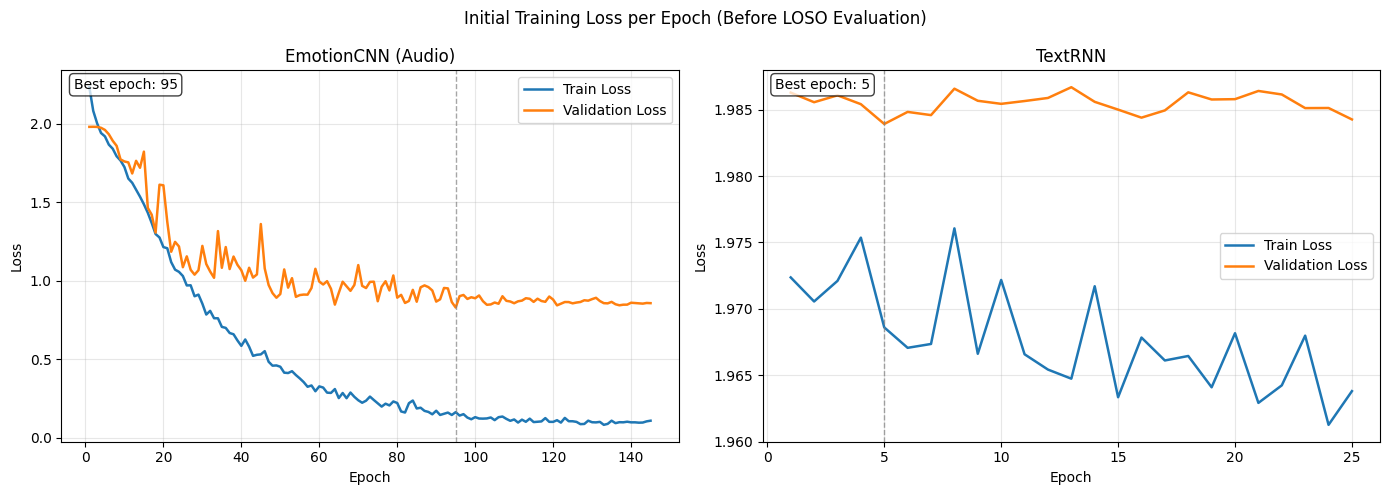

In [21]:
#====== Test Set Evaluation =============

eval_cw = audio_cw

print("=" * 40)
print("EmotionCNN (Audio) — Test Results")
print("=" * 40)
audio_test_results = evaluate_test_set(
    audio_model,
    X_audio_test,
    y_test,
    eval_cw,
)

print()

print("=" * 40)
print("TextRNN — Test Results")
print("=" * 40)
text_test_results = evaluate_test_set(
    txt_model,
    X_text_test,
    y_test,
    eval_cw,
)

plot_training_histories(
    {
        "EmotionCNN (Audio)": audio_history,
        "TextRNN": text_history,
    },
    title="Initial Training Loss per Epoch (Before LOSO Evaluation)",
)


### About LOSO Evaluation:

I decided to have my models evaluated using n-fold predictions on all Actors using LOSO (Leave One Subject out method). Here's how this works
 
1) Select an Actor (Say Actor 1). All of their audio files will be our test set
2) Choose (Without Replacement) an Actor (Aside from our Test Actor) to be the Validation Set
3) Train both the models on the remaining 22 Actors and evaluate on the test set

Repeat, by selecting the next actor for the test set and a different actor for the validation Set and do this until all actors are covered. The average of weighted Accuracy across all actors will be our final Score.


This was chosen instead of a random split evaluation as the model should find generalised features of an emotion, and not actor specific features. Everyone expresses emotion a little differently, and I'm doing this so the model doesn't learn to first identify the actor then search for actor-specific emotion features, instead of learning features that are related to the emotion in general.

In [22]:
#======== Leave One Subject Out (LOSO) Final Evaluation =====================

actors     = np.array([r["actor"] for r in records])
unique_ids = np.unique(actors)
print(f"LOSO evaluation over {len(unique_ids)} actors: {unique_ids.tolist()}\n")

os.makedirs(LOGITS_DIR, exist_ok=True)

# Each actor appears exactly once as a validation actor across all 24 folds.
rng = np.random.default_rng(RANDOM_SEED)
actors_list = unique_ids.tolist()
val_order = list(rng.permutation(actors_list))

for i in range(len(actors_list)):
    if val_order[i] == actors_list[i]:
        j = (i + 1) % len(actors_list)
        val_order[i], val_order[j] = val_order[j], val_order[i]

val_assignments = dict(zip(actors_list, val_order))
print(f"Validation assignments: {val_assignments}\n")

per_actor_acc_audio = {}
per_actor_acc_text  = {}

for fold, held_out in enumerate(unique_ids):
    print(f"\n{'='*60}")
    print(f"  LOSO Fold {fold+1}/{len(unique_ids)} — held-out actor {held_out}")
    print(f"{'='*60}")

    val_actor = val_assignments[int(held_out)]
    print(f"  Validation actor: {val_actor}")

    test_mask  = (actors == held_out)
    val_mask   = (actors == val_actor)
    train_mask = ~(test_mask | val_mask)

    X_audio_fold_train = jax.device_put(X_audio[train_mask])
    X_audio_fold_val   = jax.device_put(X_audio[val_mask])
    X_audio_fold_test  = jax.device_put(X_audio[test_mask])
    X_text_fold_train  = jax.device_put(X_text[train_mask])
    X_text_fold_val    = jax.device_put(X_text[val_mask])
    X_text_fold_test   = jax.device_put(X_text[test_mask])
    y_fold_train       = jax.device_put(y[train_mask])
    y_fold_val         = jax.device_put(y[val_mask])
    y_fold_test        = jax.device_put(y[test_mask])

    print(f"  train {y_fold_train.shape[0]} | val {y_fold_val.shape[0]} | test {y_fold_test.shape[0]}")

    # Class weights from this fold's training labels
    fold_cw = compute_class_weights(np.array(y_fold_train))
    np.save(os.path.join(LOGITS_DIR, f"fold_{held_out}_class_weights.npy"), np.array(fold_cw))

    # ------------ Audio Model--------------------------------------------
    fold_audio_model, fold_audio_opt = create_audio_model_and_optimizer()
    fm = create_metric_tracker()
    fv = create_metric_tracker()
    es_audio = EarlyStopping(patience=30)

    for epoch in range(AUDIO_EPOCHS):
        fold_audio_model.train()
        for batch in get_vram_batches(X_audio_fold_train, y_fold_train, shuffle=True, seed=epoch):
            train_step(fold_audio_model, fold_audio_opt, fm, batch, fold_cw)
        fold_audio_model.eval()
        for batch in get_vram_batches(X_audio_fold_val, y_fold_val, shuffle=False):
            eval_step(fold_audio_model, fv, batch, fold_cw)
        train_stats = metrics_to_python(fm.compute())
        vc = metrics_to_python(fv.compute())
        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"  [Audio] Epoch {epoch+1:3d} | Train {train_stats} | Val {vc}")
        fm.reset(); fv.reset()
        if es_audio.step(float(vc['loss']), fold_audio_model, epoch):
            print(f"  [Audio] Early stop at epoch {epoch+1}")
            break
    es_audio.restore(fold_audio_model)

    audio_results = evaluate_test_set(fold_audio_model, X_audio_fold_test, y_fold_test, fold_cw)
    per_actor_acc_audio[int(held_out)] = audio_results["weighted_acc"]

    # Save audio logits (val + test)
    audio_val_logits  = collect_logits(fold_audio_model, X_audio_fold_val)
    audio_test_logits = audio_results["logits"]
    np.save(os.path.join(LOGITS_DIR, f"fold_{held_out}_audio_val_logits.npy"),  audio_val_logits)
    np.save(os.path.join(LOGITS_DIR, f"fold_{held_out}_audio_test_logits.npy"), audio_test_logits)

    # ============================ Text Model=============================================================
    fold_txt_model, fold_txt_opt = create_text_model_and_optimizer(vocab_size=VOCAB_SIZE, pad_id=PAD_ID)
    fm = create_metric_tracker()
    fv = create_metric_tracker()
    es_text = EarlyStopping(patience=10)

    for epoch in range(TEXT_EPOCHS):
        fold_txt_model.train()
        for batch in get_vram_batches(X_text_fold_train, y_fold_train, shuffle=True, seed=epoch):
            train_step(fold_txt_model, fold_txt_opt, fm, batch, fold_cw)
        fold_txt_model.eval()
        for batch in get_vram_batches(X_text_fold_val, y_fold_val, shuffle=False):
            eval_step(fold_txt_model, fv, batch, fold_cw)
        train_stats = metrics_to_python(fm.compute())
        vc = metrics_to_python(fv.compute())
        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"  [Text]  Epoch {epoch+1:3d} | Train {train_stats} | Val {vc}")
        fm.reset(); fv.reset()
        if es_text.step(float(vc['loss']), fold_txt_model, epoch):
            print(f"  [Text]  Early stop at epoch {epoch+1}")
            break
    es_text.restore(fold_txt_model)

    text_results = evaluate_test_set(fold_txt_model, X_text_fold_test, y_fold_test, fold_cw)
    per_actor_acc_text[int(held_out)] = text_results["weighted_acc"]

    # Save text logits (val + test)
    text_val_logits  = collect_logits(fold_txt_model, X_text_fold_val)
    text_test_logits = text_results["logits"]
    np.save(os.path.join(LOGITS_DIR, f"fold_{held_out}_text_val_logits.npy"),  text_val_logits)
    np.save(os.path.join(LOGITS_DIR, f"fold_{held_out}_text_test_logits.npy"), text_test_logits)

    # Save ground truth labels (val + test)
    np.save(os.path.join(LOGITS_DIR, f"fold_{held_out}_val_labels.npy"),  np.array(y_fold_val))
    np.save(os.path.join(LOGITS_DIR, f"fold_{held_out}_test_labels.npy"), np.array(y_fold_test))

print("\n" + "=" * 60)
print("  LOSO Results — Per-Actor Weighted Accuracy")
print("=" * 60)
print(f"{'Actor':>7s}  {'Audio':>8s}  {'Text':>8s}")
print("-" * 30)
for aid in sorted(per_actor_acc_audio):
    print(f"{aid:>7d}  {per_actor_acc_audio[aid]:>8.4f}  {per_actor_acc_text[aid]:>8.4f}")
mean_a = np.mean(list(per_actor_acc_audio.values()))
mean_t = np.mean(list(per_actor_acc_text.values()))
print("-" * 30)
print(f"{'Mean':>7s}  {mean_a:>8.4f}  {mean_t:>8.4f}")
print("=" * 60)


LOSO evaluation over 24 actors: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

Validation assignments: {1: np.int64(17), 2: np.int64(16), 3: np.int64(19), 4: np.int64(20), 5: np.int64(10), 6: np.int64(8), 7: np.int64(18), 8: np.int64(24), 9: np.int64(7), 10: np.int64(11), 11: np.int64(4), 12: np.int64(1), 13: np.int64(21), 14: np.int64(13), 15: np.int64(6), 16: np.int64(12), 17: np.int64(15), 18: np.int64(23), 19: np.int64(3), 20: np.int64(5), 21: np.int64(22), 22: np.int64(2), 23: np.int64(14), 24: np.int64(9)}


  LOSO Fold 1/24 — held-out actor 1
  Validation actor: 17
  train 1320 | val 60 | test 60
  [Audio] Epoch   1 | Train {'loss': 2.1989312171936035, 'weighted_acc': 0.13550028204917908} | Val {'loss': 1.9648044109344482, 'weighted_acc': 0.14285710453987122}
  [Audio] Epoch  25 | Train {'loss': 0.9150822162628174, 'weighted_acc': 0.6676211357116699} | Val {'loss': 1.5186575651168823, 'weighted_acc': 0.3869047164916992}
  [Audio] Epoch  

### Why Late Fusion?

To be honest, Late fusion was more about damage control for this specific dataset rather than the optimal choice in general. As you've seen on my note on the RNN model, the Text RNN model is completely useless for this dataset. So a fusion that performs best is a fusion that takes minimum influence from the RNN model. Late fusion practically ensures the learned weights will be overwhelmingly favour the Audio model instead of the text model, threby giving nearly the same performance as the Audio model

In [23]:
# ========================= LATE FUSION MODEL================================

class LateFusion(nnx.Module):
    """Learns a scalar weight alpha to fuse softmax-normalised logits."""
    def __init__(self, rngs: nnx.Rngs):
        self.log_alpha = nnx.Param(jnp.array(0.0))

    def __call__(self, audio_probs: jnp.ndarray, text_probs: jnp.ndarray):
        alpha = jax.nn.sigmoid(self.log_alpha.value)
        return alpha * audio_probs + (1 - alpha) * text_probs


#==================== Load & Concatenate All Validation Logits=================================

all_audio_val, all_text_val, all_val_labels = [], [], []
for a in unique_ids:
    all_audio_val.append(np.load(os.path.join(LOGITS_DIR, f"fold_{a}_audio_val_logits.npy")))
    all_text_val.append(np.load(os.path.join(LOGITS_DIR, f"fold_{a}_text_val_logits.npy")))
    all_val_labels.append(np.load(os.path.join(LOGITS_DIR, f"fold_{a}_val_labels.npy")))

all_audio_val  = jnp.array(np.concatenate(all_audio_val))
all_text_val   = jnp.array(np.concatenate(all_text_val))
all_val_labels = jnp.array(np.concatenate(all_val_labels).astype(np.int32))

print(f"Fusion training data: {all_audio_val.shape[0]} samples")

# Softmax-normalise
all_audio_probs = jax.nn.softmax(all_audio_val, axis=-1)
all_text_probs  = jax.nn.softmax(all_text_val,  axis=-1)

# Class weights for the pooled validation set
fusion_cw = compute_class_weights(np.array(all_val_labels))

# ===================== Train the Fusion Model ==============================

fusion_model = LateFusion(rngs=nnx.Rngs(params=0))
fusion_opt   = nnx.Optimizer(fusion_model, optax.adam(1e-2), wrt=nnx.Param)

@nnx.jit
def fusion_train_step(model, opt, audio_p, text_p, labels, cw):
    def loss_fn(m):
        fused = m(audio_p, text_p)
        return weighted_xent(fused, labels, cw)
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    opt.update(model, grads)
    return loss

FUSION_EPOCHS = 500
for ep in range(FUSION_EPOCHS):
    loss = fusion_train_step(fusion_model, fusion_opt,
                             all_audio_probs, all_text_probs,
                             all_val_labels, fusion_cw)
    if (ep + 1) % 100 == 0 or ep == 0:
        alpha = float(jax.nn.sigmoid(fusion_model.log_alpha.value))
        print(f"  Fusion Epoch {ep+1:3d} | Loss {float(loss):.4f} | alpha={alpha:.4f}")

learned_alpha = float(jax.nn.sigmoid(fusion_model.log_alpha.value))
print(f"\nLearned fusion weight: alpha={learned_alpha:.4f}  (audio={learned_alpha:.2%}, text={1-learned_alpha:.2%})")


Fusion training data: 1440 samples
  Fusion Epoch   1 | Loss 1.7769 | alpha=0.5025
  Fusion Epoch 100 | Loss 1.6962 | alpha=0.7226
  Fusion Epoch 200 | Loss 1.6525 | alpha=0.8473
  Fusion Epoch 300 | Loss 1.6323 | alpha=0.9066
  Fusion Epoch 400 | Loss 1.6220 | alpha=0.9371
  Fusion Epoch 500 | Loss 1.6162 | alpha=0.9547

Learned fusion weight: alpha=0.9547  (audio=95.47%, text=4.53%)



  Fused Model LOSO Evaluation
  Actor  1 | Weighted Acc: 0.6406 | Balanced Acc: 0.6406 | Regular Acc: 0.6167
  Actor  2 | Weighted Acc: 0.7969 | Balanced Acc: 0.7969 | Regular Acc: 0.7833
  Actor  3 | Weighted Acc: 0.5000 | Balanced Acc: 0.5000 | Regular Acc: 0.4833
  Actor  4 | Weighted Acc: 0.6250 | Balanced Acc: 0.6250 | Regular Acc: 0.6000
  Actor  5 | Weighted Acc: 0.5781 | Balanced Acc: 0.5781 | Regular Acc: 0.6167
  Actor  6 | Weighted Acc: 0.6875 | Balanced Acc: 0.6875 | Regular Acc: 0.6667
  Actor  7 | Weighted Acc: 0.5938 | Balanced Acc: 0.5938 | Regular Acc: 0.6333
  Actor  8 | Weighted Acc: 0.7656 | Balanced Acc: 0.7656 | Regular Acc: 0.7500
  Actor  9 | Weighted Acc: 0.3594 | Balanced Acc: 0.3594 | Regular Acc: 0.3833
  Actor 10 | Weighted Acc: 0.5312 | Balanced Acc: 0.5312 | Regular Acc: 0.5333
  Actor 11 | Weighted Acc: 0.6250 | Balanced Acc: 0.6250 | Regular Acc: 0.6333
  Actor 12 | Weighted Acc: 0.7344 | Balanced Acc: 0.7344 | Regular Acc: 0.7333
  Actor 13 | Weighted

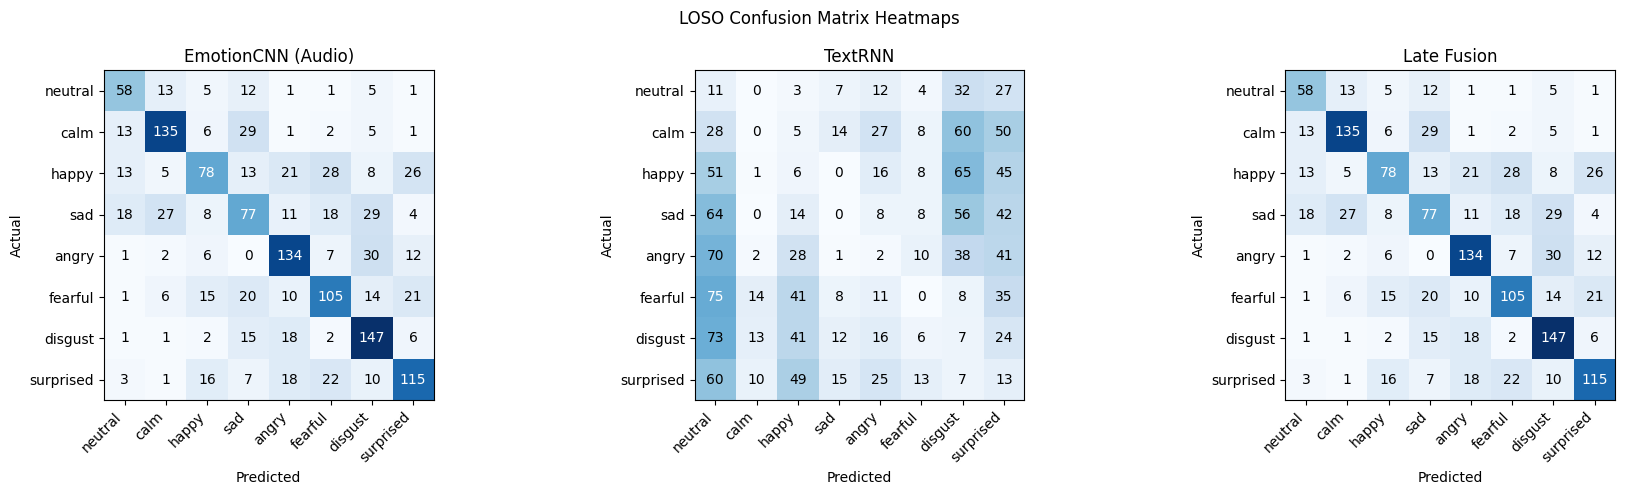

In [24]:
# ======================FINAL FUSED MODEL LOSO EVALUATION==================

per_actor_acc_fused = {}

all_labels = []
all_audio_preds = []
all_text_preds = []
all_fused_preds = []
all_sample_weights = []

print("\n" + "=" * 60)
print("  Fused Model LOSO Evaluation")
print("=" * 60)

for held_out in unique_ids:
    # Load saved test logits and labels
    audio_test = np.load(os.path.join(LOGITS_DIR, f"fold_{held_out}_audio_test_logits.npy"))
    text_test  = np.load(os.path.join(LOGITS_DIR, f"fold_{held_out}_text_test_logits.npy"))
    test_labels = np.load(os.path.join(LOGITS_DIR, f"fold_{held_out}_test_labels.npy"))
    fold_cw = np.load(os.path.join(LOGITS_DIR, f"fold_{held_out}_class_weights.npy"))

    # Softmax-normalise
    audio_probs = jax.nn.softmax(jnp.array(audio_test), axis=-1)
    text_probs  = jax.nn.softmax(jnp.array(text_test),  axis=-1)

    # Apply learned fusion
    fused_probs = np.array(fusion_model(audio_probs, text_probs))

    audio_preds = np.argmax(audio_test, axis=-1)
    text_preds = np.argmax(text_test, axis=-1)
    fused_preds = np.argmax(fused_probs, axis=-1)

    fold_results = compute_prediction_metrics(
        test_labels,
        fused_preds,
        class_weights=fold_cw,
    )
    per_actor_acc_fused[int(held_out)] = fold_results["weighted_acc"]
    print(
        f"  Actor {held_out:2d} | Weighted Acc: {fold_results['weighted_acc']:.4f} "
        f"| Balanced Acc: {fold_results['balanced_acc']:.4f} | Regular Acc: {fold_results['accuracy']:.4f}"
    )

    all_labels.append(test_labels)
    all_audio_preds.append(audio_preds)
    all_text_preds.append(text_preds)
    all_fused_preds.append(fused_preds)
    all_sample_weights.append(np.asarray(fold_cw)[test_labels])

all_labels = np.concatenate(all_labels)
all_audio_preds = np.concatenate(all_audio_preds)
all_text_preds = np.concatenate(all_text_preds)
all_fused_preds = np.concatenate(all_fused_preds)
all_sample_weights = np.concatenate(all_sample_weights)

audio_loso_results = compute_prediction_metrics(
    all_labels,
    all_audio_preds,
    sample_weights=all_sample_weights,
)
text_loso_results = compute_prediction_metrics(
    all_labels,
    all_text_preds,
    sample_weights=all_sample_weights,
)
fused_loso_results = compute_prediction_metrics(
    all_labels,
    all_fused_preds,
    sample_weights=all_sample_weights,
)

print("\n" + "=" * 60)
print("  LOSO Results — All Models Comparison (Weighted Accuracy)")
print("=" * 60)
print(f"{'Actor':>7s}  {'Audio':>8s}  {'Text':>8s}  {'Fused':>8s}")
print("-" * 40)
for aid in sorted(per_actor_acc_audio):
    print(f"{aid:>7d}  {per_actor_acc_audio[aid]:>8.4f}  {per_actor_acc_text[aid]:>8.4f}  {per_actor_acc_fused[aid]:>8.4f}")
mean_a = np.mean(list(per_actor_acc_audio.values()))
mean_t = np.mean(list(per_actor_acc_text.values()))
mean_f = np.mean(list(per_actor_acc_fused.values()))
print("-" * 40)
print(f"{'Mean':>7s}  {mean_a:>8.4f}  {mean_t:>8.4f}  {mean_f:>8.4f}")
print("=" * 60)
print(f"\nLearned fusion alpha: {learned_alpha:.4f}")

print()
print_evaluation_summary(audio_loso_results, title="EmotionCNN (Audio) — LOSO Aggregate Metrics")
print_evaluation_summary(text_loso_results, title="TextRNN — LOSO Aggregate Metrics")
print_evaluation_summary(fused_loso_results, title="Late Fusion — LOSO Aggregate Metrics")

plot_confusion_heatmaps(
    {
        "EmotionCNN (Audio)": audio_loso_results,
        "TextRNN": text_loso_results,
        "Late Fusion": fused_loso_results,
    },
    title="LOSO Confusion Matrix Heatmaps",
)
